<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_066_multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 66/365 — Multiclass Classification
## What if the model must choose between more than two classes?

Binary classification chooses between two classes.

Multiclass classification chooses one class from three or more possibilities.

Examples:
- Billing / Technical / Account / Other
- Cat / Dog / Horse
- Product category
- Document topic


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 1. Load the Iris dataset


In [2]:
data=load_iris(as_frame=True)
X=data.data
y=data.target

print("Classes:",list(data.target_names))
print("Dataset shape:",X.shape)

display(X.head())


Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. Train/test split


In [3]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


## 3. Train multiclass Logistic Regression


In [4]:
model=LogisticRegression(max_iter=2000)

model.fit(X_train,y_train)
pred=model.predict(X_test)

print("Accuracy:",round(accuracy_score(y_test,pred),3))
print()
print(classification_report(
    y_test,
    pred,
    target_names=data.target_names,
    digits=3
))


Accuracy: 0.947

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        12
  versicolor      0.923     0.923     0.923        13
   virginica      0.923     0.923     0.923        13

    accuracy                          0.947        38
   macro avg      0.949     0.949     0.949        38
weighted avg      0.947     0.947     0.947        38



## 4. Inspect predicted probabilities


In [5]:
probabilities=model.predict_proba(X_test[:5])

prob_df=pd.DataFrame(
    probabilities,
    columns=data.target_names
)

prob_df["Predicted Class"]=[
    data.target_names[i]
    for i in probabilities.argmax(axis=1)
]

display(prob_df.round(3))


,setosa,versicolor,virginica,Predicted Class
0,0.987,0.013,0.000,setosa
1,0.006,0.662,0.333,versicolor
2,0.027,0.919,0.054,versicolor
3,0.022,0.933,0.045,versicolor
4,0.983,0.017,0.000,setosa


## 5. Multiclass Confusion Matrix


In [6]:
cm=confusion_matrix(y_test,pred)

cm_df=pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in data.target_names],
    columns=[f"Pred {name}" for name in data.target_names]
)

display(cm_df)


,Pred setosa,Pred versicolor,Pred virginica
Actual setosa,12,0,0
Actual versicolor,0,12,1
Actual virginica,0,1,12


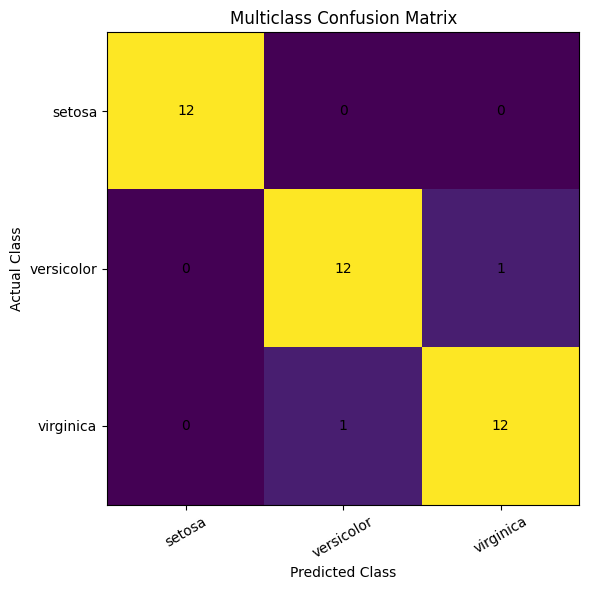

In [7]:
plt.figure(figsize=(7,6))
plt.imshow(cm)

plt.xticks(
    range(len(data.target_names)),
    data.target_names,
    rotation=30
)

plt.yticks(
    range(len(data.target_names)),
    data.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Multiclass Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha="center",va="center")

plt.tight_layout()
plt.show()


## 6. One-vs-Rest (OvR)

For 3 classes:

- A vs everything else
- B vs everything else
- C vs everything else

Each classifier gives a score.

The strongest score wins.


In [8]:
ovr_model=OneVsRestClassifier(
    LogisticRegression(max_iter=2000)
)

ovr_model.fit(X_train,y_train)

ovr_pred=ovr_model.predict(X_test)

print(
    "One-vs-Rest Accuracy:",
    round(accuracy_score(y_test,ovr_pred),3)
)


One-vs-Rest Accuracy: 0.895


## 7. One-vs-One (OvO)

For 3 classes:

- A vs B
- A vs C
- B vs C

Each pairwise classifier votes.

SVM commonly uses a one-vs-one strategy for multiclass classification.


## 8. Multiclass metrics

Precision, Recall and F1 can be summarized using different averaging strategies.

### Macro
Calculate the metric for each class, then average equally.

### Weighted
Average class metrics weighted by class frequency.

### Micro
Combine all TP, FP and FN counts first, then calculate the metric.


## 9. Enterprise intuition

Multiclass classification appears in:

- customer-support routing
- incident categorization
- document classification
- product categorization
- ticket triage
- intent classification

Example:

A support ticket may be classified as exactly one of:

`Billing / Technical / Account / Cancellation`


## 10. Multiclass vs Multilabel

### Multiclass
One sample belongs to exactly one class.

Example:

`Billing OR Technical OR Account`

### Multilabel
One sample can belong to several labels.

Example:

`Finance + Compliance`

These are different machine-learning problems.


## What does this teach?

- Multiclass means choosing one class from 3 or more possibilities.
- Logistic Regression can handle multiclass problems.
- One-vs-Rest converts multiclass into several binary problems.
- One-vs-One compares classes pairwise.
- Confusion matrices extend naturally to multiple classes.
- Macro, Micro and Weighted averages summarize performance differently.
- Multiclass is different from multilabel classification.

> **Binary classification asks: A or B? Multiclass asks: which one among many?**


## References

- https://scikit-learn.org/stable/modules/multiclass.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
